In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc
import sklearn
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_train = pd.read_csv('train_main.csv')

In [4]:
target_column = 'r/h or l/h'
target_index = df_train.columns.get_loc(target_column)

In [5]:
columns_to_keep = df_train.columns[:target_index + 1].tolist()

In [6]:
df_1 = df_train[columns_to_keep]

In [7]:
df_1.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),"Feed rate (D, mm/min)",Surface roughness (SR),Wall Angle (degree,r/h or l/h
0,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,0.2,2500.0,500.0,1.74,78.89,5.102
1,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.2,2500.0,500.0,1.45,75.11,5.102
2,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,1,2500.0,500.0,6.91,73.68,5.102
3,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,1,2500.0,500.0,3.91,68.32,5.102
4,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.6,2500.0,1000.0,2.66,77.63,5.102


In [8]:
df_1.shape

(501, 14)

In [9]:
df_1.dtypes

YS (MPa)                               float64
UTS (MPa)                              float64
K (Mpa)                                float64
n                                      float64
Lankford anisotropy coefficient (r)    float64
Category                                object
Thickness                              float64
Tool diameter (A, mm)                  float64
Step size (B, mm)                       object
Spindle Speed (rpm)                    float64
Feed rate (D, mm/min)                  float64
Surface roughness (SR)                 float64
Wall Angle (degree                      object
r/h or l/h                             float64
dtype: object

In [10]:
df_1.isnull().sum()

YS (MPa)                                0
UTS (MPa)                               0
K (Mpa)                                 0
n                                       0
Lankford anisotropy coefficient (r)     0
Category                                0
Thickness                               0
Tool diameter (A, mm)                   0
Step size (B, mm)                       0
Spindle Speed (rpm)                    46
Feed rate (D, mm/min)                   0
Surface roughness (SR)                  0
Wall Angle (degree                     66
r/h or l/h                             27
dtype: int64

In [11]:
# Apply target encoding on Category
encoding_map = df_1.groupby('Category')['n'].median()
df_1['Category_encoded'] = df_1['Category'].map(encoding_map)

# Get column index of Category after encoding
category_index = df_1.columns.get_loc('Category')
print("Category column index after encoding:", category_index)


Category column index after encoding: 5


In [12]:
df_1.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),"Feed rate (D, mm/min)",Surface roughness (SR),Wall Angle (degree,r/h or l/h,Category_encoded
0,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,0.2,2500.0,500.0,1.74,78.89,5.102,0.14
1,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.2,2500.0,500.0,1.45,75.11,5.102,0.14
2,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,1,2500.0,500.0,6.91,73.68,5.102,0.14
3,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,1,2500.0,500.0,3.91,68.32,5.102,0.14
4,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.6,2500.0,1000.0,2.66,77.63,5.102,0.14


In [13]:
df_1['Step size (B, mm)'] = df_1['Step size (B, mm)'].astype(str).str.replace(',', '.', regex = False)
df_1['Step size (B, mm)'] = df_1['Step size (B, mm)'].astype(float)

In [14]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors = 3, weights = 'uniform')

In [15]:
df_1['Spindle Speed (rpm)'] = imputer.fit_transform(df_1[['Spindle Speed (rpm)']])

In [16]:
df_1['Wall Angle (degree'] = df_1['Wall Angle (degree'].astype(str).str.replace(',', '.', regex = False)
df_1['Wall Angle (degree'] = df_1['Wall Angle (degree'].astype(float)

df_1['Wall Angle (degree'] = imputer.fit_transform(df_1[['Wall Angle (degree']])

In [17]:
df_1['r/h or l/h'] = imputer.fit_transform(df_1[['r/h or l/h']])

In [18]:
df_1['MRR'] = df_1['Step size (B, mm)'] * df_1['Feed rate (D, mm/min)'] * df_1['Thickness']
df_1['Cutting_Speed'] = (np.pi * df_1['Tool diameter (A, mm)'] * df_1['Spindle Speed (rpm)']) / 1000
df_1['Formability_index'] = df_1['n'] * df_1['Lankford anisotropy coefficient (r)']
df_1['Strength_ratio'] = df_1['YS (MPa)'] / df_1['UTS (MPa)']
df_1['Work_hardening_capacity'] = df_1['K (Mpa)'] / df_1['UTS (MPa)']
df_1['Material_toughness'] = df_1['n'] * df_1['UTS (MPa)']
df_1['Tool_thickness_ratio'] = df_1['Tool diameter (A, mm)'] / df_1['Thickness']
df_1['Incremental_strain_rate'] = df_1['Feed rate (D, mm/min)'] / df_1['Step size (B, mm)']

In [19]:
df_1.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),...,r/h or l/h,Category_encoded,MRR,Cutting_Speed,Formability_index,Strength_ratio,Work_hardening_capacity,Material_toughness,Tool_thickness_ratio,Incremental_strain_rate
0,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,0.2,2500.0,...,5.102,0.14,70.0,31.415927,0.0605,0.882017,1.598517,21.3598,5.714286,2500.000000
1,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.2,2500.0,...,5.102,0.14,70.0,78.539816,0.0605,0.882017,1.598517,21.3598,14.285714,2500.000000
2,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,1.0,2500.0,...,5.102,0.14,350.0,31.415927,0.0605,0.882017,1.598517,21.3598,5.714286,500.000000
3,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,1.0,2500.0,...,5.102,0.14,350.0,78.539816,0.0605,0.882017,1.598517,21.3598,14.285714,500.000000
4,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.6,2500.0,...,5.102,0.14,420.0,78.539816,0.0605,0.882017,1.598517,21.3598,14.285714,1666.666667


In [20]:
df_1 = df_1.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 11, 12, 13]]

In [21]:
df_1.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),...,Cutting_Speed,Formability_index,Strength_ratio,Work_hardening_capacity,Material_toughness,Tool_thickness_ratio,Incremental_strain_rate,Surface roughness (SR),Wall Angle (degree,r/h or l/h
0,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,0.2,2500.0,...,31.415927,0.0605,0.882017,1.598517,21.3598,5.714286,2500.000000,1.74,78.89,5.102
1,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.2,2500.0,...,78.539816,0.0605,0.882017,1.598517,21.3598,14.285714,2500.000000,1.45,75.11,5.102
2,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,4.0,1.0,2500.0,...,31.415927,0.0605,0.882017,1.598517,21.3598,5.714286,500.000000,6.91,73.68,5.102
3,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,1.0,2500.0,...,78.539816,0.0605,0.882017,1.598517,21.3598,14.285714,500.000000,3.91,68.32,5.102
4,171.27,194.18,310.4,0.11,0.55,variable angle conical shaped part,0.7,10.0,0.6,2500.0,...,78.539816,0.0605,0.882017,1.598517,21.3598,14.285714,1666.666667,2.66,77.63,5.102


In [22]:
# Separate features and target (here Category is target)
X = df_1.drop(columns = ['Category'])
Y = df_1['Category']

print("Before SMOTE:", Counter(Y))

# Apply SMOTE to balance classes
adasyn = SMOTE(random_state = 42, k_neighbors = 5)
X_resampled, Y_resampled = adasyn.fit_resample(X, Y)

print("After SMOTE:", Counter(Y_resampled))

# Combine back into a balanced DataFrame
df_1 = pd.DataFrame(X_resampled, columns = X.columns)
df_1['Category'] = Y_resampled

Before SMOTE: Counter({'truncated cone with constant angle': 223, 'Square frustum with constant angle': 91, 'Square+circular base and conical': 46, 'variable angle conical shaped part': 44, 'truncated cone with variable angle': 27, 'Square-shaped constant angle': 25, 'variable angle circular shaped part': 18, 'Square frustum with variable angle': 18, 'Hexagon with constant angle': 9})
After SMOTE: Counter({'variable angle conical shaped part': 223, 'Square+circular base and conical': 223, 'variable angle circular shaped part': 223, 'Square-shaped constant angle': 223, 'Square frustum with constant angle': 223, 'Hexagon with constant angle': 223, 'truncated cone with constant angle': 223, 'truncated cone with variable angle': 223, 'Square frustum with variable angle': 223})


In [23]:
df_1.to_csv("C://Users/kanod/Desktop/Shamik Sir/Train_SMOTE.csv", index = False)
print("Resampled dataset saved as Train_SMOTE.csv")

Resampled dataset saved as Train_SMOTE.csv


In [24]:
df_1 = df_1.drop('Category', axis = 1)

In [25]:
df_1.shape

(2007, 22)

In [26]:
# corr_matrix = df_1.corr()
# Compute correlation only for numeric columns
corr_matrix = df_1.select_dtypes(include=['number']).corr()


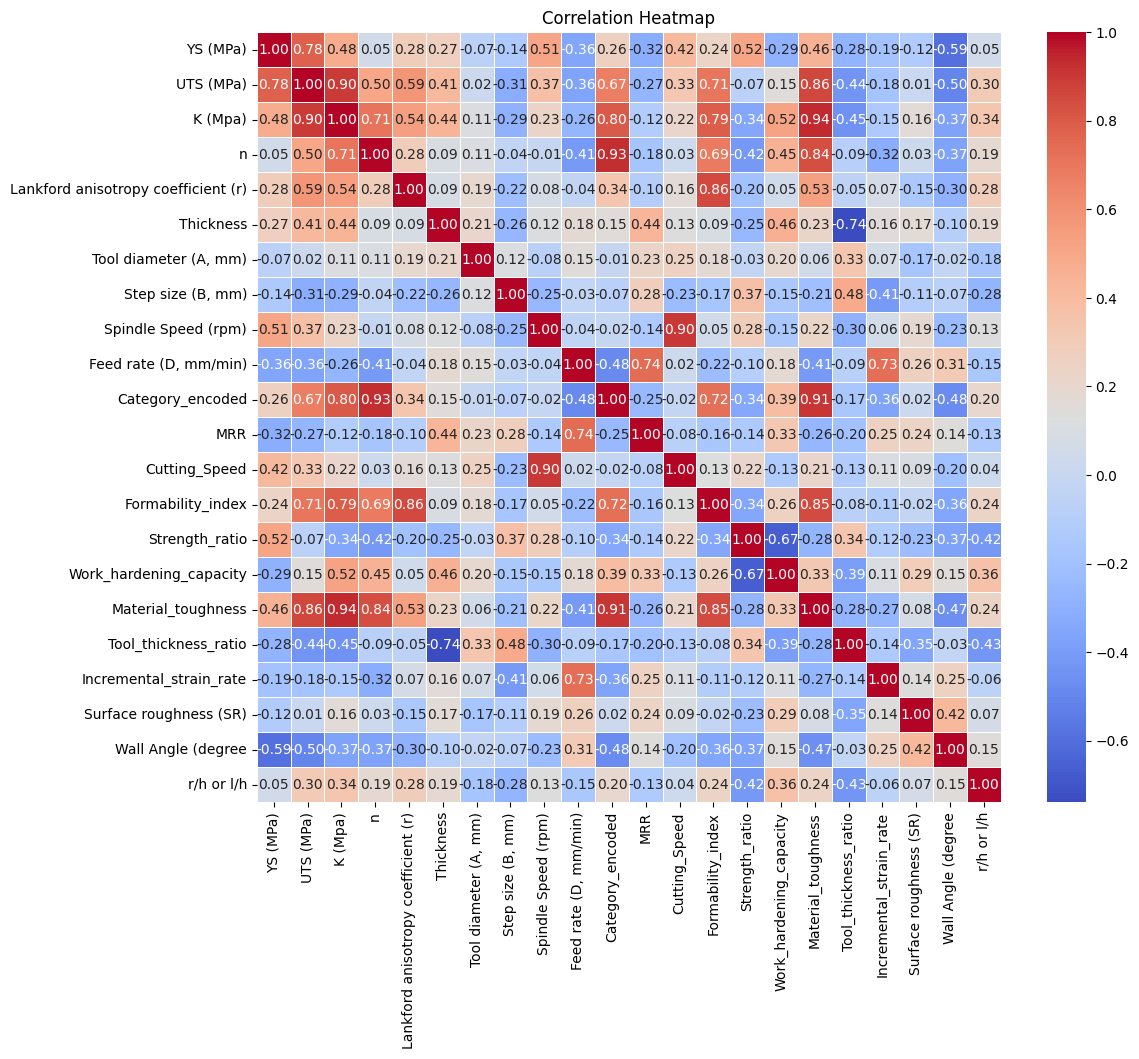

In [27]:
plt.figure(figsize = (12, 10))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
plt.title('Correlation Heatmap')
plt.show()

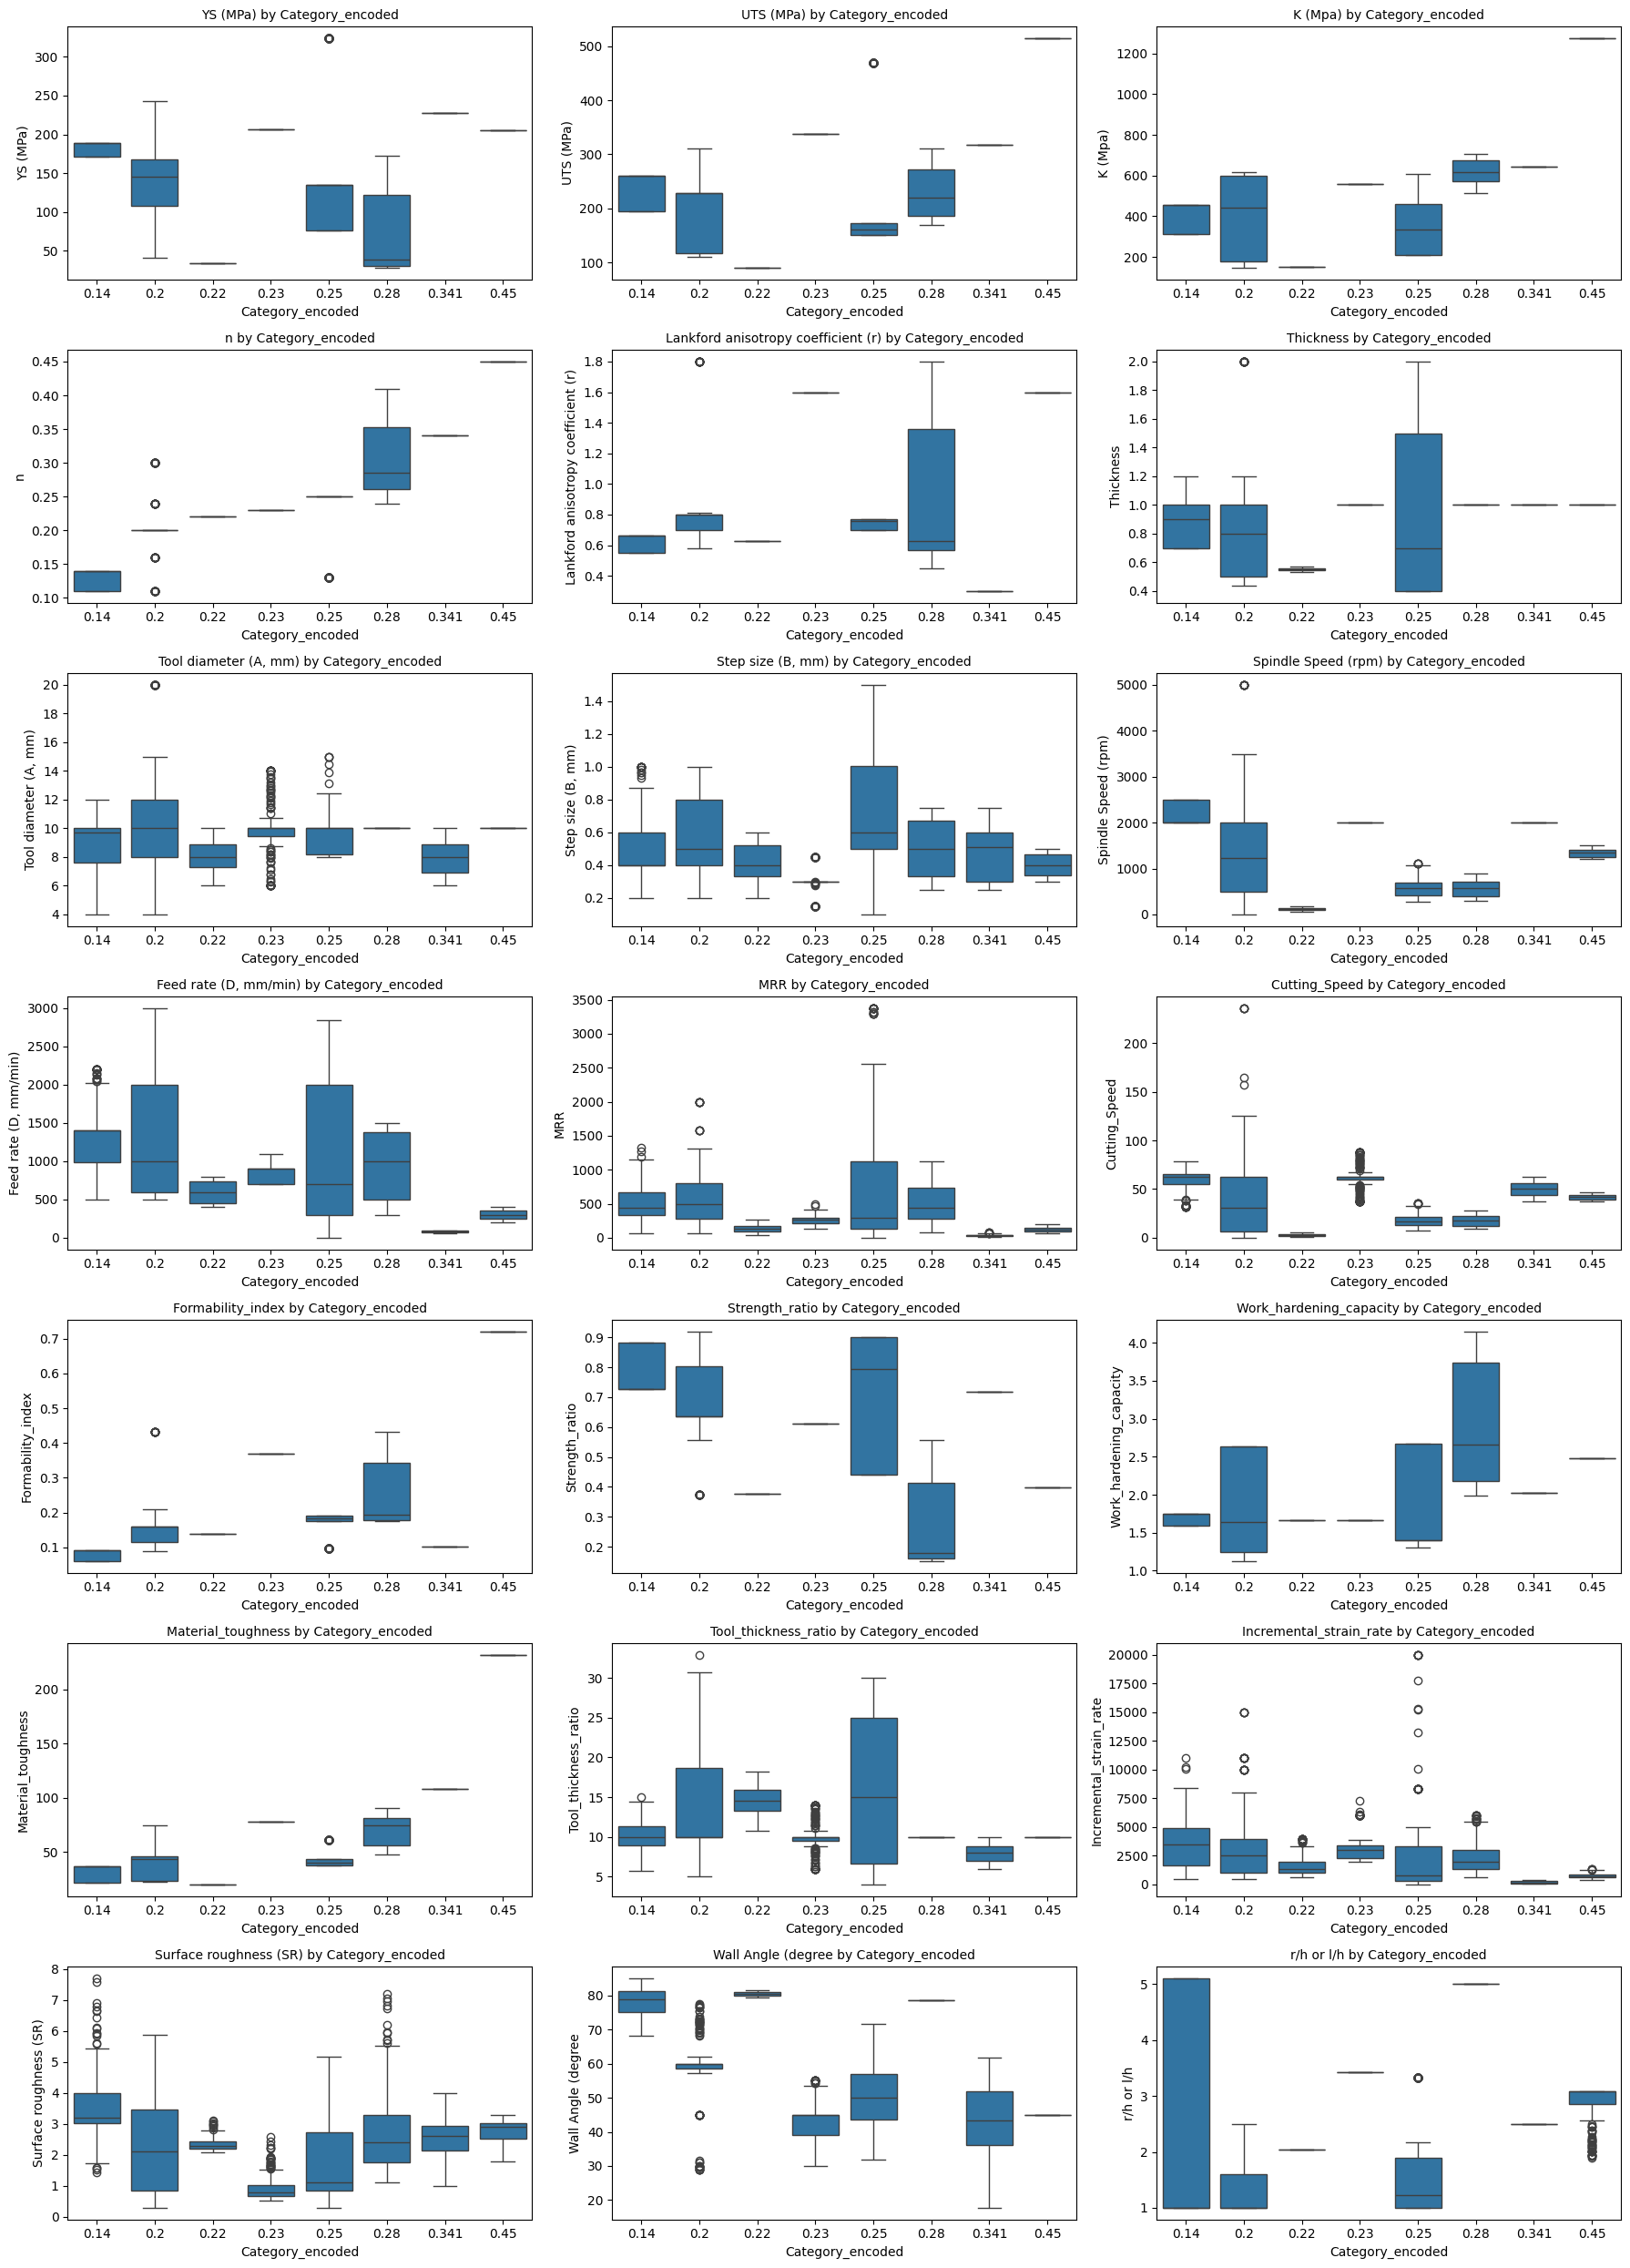

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'YS (MPa)', 'UTS (MPa)', 'K (Mpa)', 'n', 'Lankford anisotropy coefficient (r)', 'Thickness', 'Tool diameter (A, mm)', 'Step size (B, mm)', 'Spindle Speed (rpm)', 'Feed rate (D, mm/min)', 'MRR', 'Cutting_Speed' ,'Formability_index' ,'Strength_ratio' ,'Work_hardening_capacity' ,'Material_toughness' ,'Tool_thickness_ratio' ,'Incremental_strain_rate', 'Surface roughness (SR)', 'Wall Angle (degree', 'r/h or l/h'
]

rows = 7
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_1, x='Category_encoded', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Category_encoded', fontsize=10)

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import numpy as np

# Use only numeric columns
data = df_1.select_dtypes(include=[np.number])

# Compute covariance matrix
cov_matrix = np.cov(data, rowvar=False)

# Invert covariance matrix to get precision matrix
precision_matrix = np.linalg.inv(cov_matrix)

# Compute partial correlation matrix
p_corr_matrix = np.zeros_like(precision_matrix)

for i in range(len(precision_matrix)):
    for j in range(len(precision_matrix)):
        if i == j:
            p_corr_matrix[i, j] = 1
        else:
            p_corr_matrix[i, j] = -precision_matrix[i, j] / (
                np.sqrt(precision_matrix[i, i] * precision_matrix[j, j])
            )

# Convert to DataFrame for readability
partial_corr_df = pd.DataFrame(
    p_corr_matrix, index=data.columns, columns=data.columns
)

print("\nPartial Correlation Matrix:\n")
print(partial_corr_df)
# Flatten and filter pairs (i != j)
pairs = []
cols = data.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], p_corr_matrix[i, j]))

# Convert to DataFrame
pairs_df = pd.DataFrame(pairs, columns=['Var1', 'Var2', 'Partial_Correlation'])

# Sort by absolute correlation
pairs_df['AbsVal'] = pairs_df['Partial_Correlation'].abs()
pairs_df = pairs_df.sort_values(by='AbsVal', ascending=False).drop('AbsVal', axis=1)

print("\nTop Partial Correlations:\n")
print(pairs_df.head(10))



Partial Correlation Matrix:

                                     YS (MPa)  UTS (MPa)   K (Mpa)         n  \
YS (MPa)                             1.000000   0.813673 -0.312841 -0.370307   
UTS (MPa)                            0.813673   1.000000  0.733263  0.520320   
K (Mpa)                             -0.312841   0.733263  1.000000 -0.768536   
n                                   -0.370307   0.520320 -0.768536  1.000000   
Lankford anisotropy coefficient (r)  0.750701  -0.535961  0.348218  0.490151   
Thickness                           -0.224188   0.369129 -0.121210  0.030906   
Tool diameter (A, mm)                0.240925  -0.365869  0.257516  0.223730   
Step size (B, mm)                   -0.268256   0.232824 -0.073980  0.000674   
Spindle Speed (rpm)                  0.091017  -0.042073 -0.148175 -0.142169   
Feed rate (D, mm/min)               -0.254113   0.238513 -0.070078 -0.075959   
Category_encoded                     0.453121  -0.145493 -0.297503 -0.003071   
MRR       

In [30]:
import pandas as pd

# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_1.quantile(0.25)
Q3 = df_1.quantile(0.75)
IQR = Q3 - Q1

# Filter out rows where any column value is outside 1.5 * IQR
df_1_no_outliers = df_1[~((df_1 < (Q1 - 1.5 * IQR)) | (df_1 > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original shape: {df_1.shape}")
print(f"After removing outliers: {df_1_no_outliers.shape}")


Original shape: (2007, 22)
After removing outliers: (1151, 22)


In [31]:
x = df_1.iloc[:, :19].values
y = df_1.iloc[:, 19:].values

In [32]:
x.shape

(2007, 19)

In [33]:
y.shape

(2007, 3)

In [34]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [35]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_val = sc_x.transform(x_val)

In [36]:
y_train

array([[ 2.90896546, 45.        ,  3.08      ],
       [ 0.72778093, 45.        ,  3.42      ],
       [ 2.32      , 56.5       ,  1.66111404],
       ...,
       [ 0.92344681, 44.91473118,  1.        ],
       [ 2.39062891, 45.        ,  2.16587895],
       [ 2.58873926, 45.        ,  3.08      ]])

In [37]:
sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_val = sc_y.transform(y_val)

In [38]:
ann = tf.keras.models.Sequential()

In [39]:
ann.add(tf.keras.layers.Dense(units = 512, activation = 'swish', input_shape = (19,)))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.4))

In [40]:
ann.add(tf.keras.layers.Dense(units = 256, activation = 'swish'))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.3))

In [41]:
ann.add(tf.keras.layers.Dense(units = 128, activation = 'swish'))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.3))

In [42]:
ann.add(tf.keras.layers.Dense(units = 64, activation = 'swish'))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.2))

In [43]:
ann.add(tf.keras.layers.Dense(units = 32, activation = 'swish'))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.2))

In [44]:
ann.add(tf.keras.layers.Dense(units = 16, activation = 'swish'))
ann.add(tf.keras.layers.BatchNormalization())

In [45]:
ann.add(tf.keras.layers.Dense(units = 3))

In [46]:
from tensorflow.keras.optimizers import AdamW
ann.compile(optimizer = AdamW(learning_rate = 1e-3, weight_decay = 1e-5), loss = 'mae', metrics = ['mae'])

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
check_point = ModelCheckpoint('best_model.keras', save_best_only = True, monitor = 'val_mae', mode = 'min')
early_stop = EarlyStopping(monitor = 'val_mae', patience = 10, restore_best_weights = True, verbose = 1)
reduce_lr = ReduceLROnPlateau(monitor = 'val_mae', patience = 5, factor = 0.5, min_lr = 1e-6, verbose = 1)

In [48]:
ann.fit(x_train, y_train, epochs = 200, batch_size = 32, validation_data = (x_val, y_val), callbacks = [check_point, early_stop, reduce_lr], verbose = 1)

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 1.0570 - mae: 1.0570 - val_loss: 0.8223 - val_mae: 0.8223 - learning_rate: 0.0010
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7357 - mae: 0.7357 - val_loss: 0.7613 - val_mae: 0.7613 - learning_rate: 0.0010
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6154 - mae: 0.6154 - val_loss: 0.6610 - val_mae: 0.6610 - learning_rate: 0.0010
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5587 - mae: 0.5587 - val_loss: 0.5274 - val_mae: 0.5274 - learning_rate: 0.0010
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4976 - mae: 0.4976 - val_loss: 0.4079 - val_mae: 0.4079 - learning_rate: 0.0010
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4622 - mae: 0.4622 - val_loss: 0.3452 - val_mae: 0.3452 - learning_rate: 0.0010
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4508 - mae: 0.4508 - val_loss: 0.3256 - val_mae: 0.3256 - learning_rate: 0.0010
Epoch 8/20

In [49]:
df_test = pd.read_excel('Test.xlsx')

In [50]:
df_test.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),"Feed rate (D, mm/min)",Surface roughness (SR),Wall Angle (degree,r/h or l/h,height
0,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,200,400,Not Known,Not Known,0.3125,48.00
1,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,200,400,Not Known,Not Known,0.1923,52.00
2,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,400,1400,Not Known,Not Known,0.4234,35.42
3,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,400,1400,Not Known,Not Known,0.5006,39.95


In [51]:
df_height = df_test.iloc[:, 10].values
print(df_height)

[ 400  400 1400 1400]


In [52]:
df_test = df_test.drop('height', axis = 1)

In [53]:
df_test.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),"Feed rate (D, mm/min)",Surface roughness (SR),Wall Angle (degree,r/h or l/h
0,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,200,400,Not Known,Not Known,0.3125
1,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,200,400,Not Known,Not Known,0.1923
2,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,400,1400,Not Known,Not Known,0.4234
3,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,400,1400,Not Known,Not Known,0.5006


In [54]:
# Apply target encoding to test set using the same mapping as train
df_test['Category_encoded'] = df_test['Category'].map(encoding_map)

df_test

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),"Feed rate (D, mm/min)",Surface roughness (SR),Wall Angle (degree,r/h or l/h,Category_encoded
0,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,200,400,Not Known,Not Known,0.3125,0.14
1,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,200,400,Not Known,Not Known,0.1923,0.14
2,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,400,1400,Not Known,Not Known,0.4234,0.14
3,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,400,1400,Not Known,Not Known,0.5006,0.14


In [55]:
df_test['MRR'] = df_test['Step size (B, mm)'] * df_test['Feed rate (D, mm/min)'] * df_test['Thickness']
df_test['Cutting_Speed'] = (np.pi * df_test['Tool diameter (A, mm)'] * df_test['Spindle Speed (rpm)']) / 1000
df_test['Formability_index'] = df_test['n'] * df_test['Lankford anisotropy coefficient (r)']
df_test['Strength_ratio'] = df_test['YS (MPa)'] / df_test['UTS (MPa)']
df_test['Work_hardening_capacity'] = df_test['K (Mpa)'] / df_test['UTS (MPa)']
df_test['Material_toughness'] = df_test['n'] * df_test['UTS (MPa)']
df_test['Tool_thickness_ratio'] = df_test['Tool diameter (A, mm)'] / df_test['Thickness']
df_test['Incremental_strain_rate'] = df_test['Feed rate (D, mm/min)'] / df_test['Step size (B, mm)']

In [56]:
df_test.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),...,r/h or l/h,Category_encoded,MRR,Cutting_Speed,Formability_index,Strength_ratio,Work_hardening_capacity,Material_toughness,Tool_thickness_ratio,Incremental_strain_rate
0,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,200,...,0.3125,0.14,80.0,6.283185,0.29900,0.707191,1.703839,65.6400,10.000000,2000.0
1,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,200,...,0.1923,0.14,120.0,6.283185,0.33787,0.709162,1.748109,80.6594,6.666667,2000.0
2,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,400,...,0.4234,0.14,280.0,12.566371,0.29900,0.707191,1.703839,65.6400,10.000000,7000.0
3,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,400,...,0.5006,0.14,420.0,12.566371,0.33787,0.709162,1.748109,80.6594,6.666667,7000.0


In [57]:
df_test = df_test.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 11, 12, 13]]

In [58]:
df_test.head()

,YS (MPa),UTS (MPa),K (Mpa),n,Lankford anisotropy coefficient (r),Category,Thickness,"Tool diameter (A, mm)","Step size (B, mm)",Spindle Speed (rpm),...,Cutting_Speed,Formability_index,Strength_ratio,Work_hardening_capacity,Material_toughness,Tool_thickness_ratio,Incremental_strain_rate,Surface roughness (SR),Wall Angle (degree,r/h or l/h
0,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,200,...,6.283185,0.29900,0.707191,1.703839,65.6400,10.000000,2000.0,Not Known,Not Known,0.3125
1,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,200,...,6.283185,0.33787,0.709162,1.748109,80.6594,6.666667,2000.0,Not Known,Not Known,0.1923
2,232.1,328.2,559.2,0.200,1.495,variable angle conical shaped part,1.0,10,0.2,400,...,12.566371,0.29900,0.707191,1.703839,65.6400,10.000000,7000.0,Not Known,Not Known,0.4234
3,253.1,356.9,623.9,0.226,1.495,variable angle conical shaped part,1.5,10,0.2,400,...,12.566371,0.33787,0.709162,1.748109,80.6594,6.666667,7000.0,Not Known,Not Known,0.5006


In [59]:
df_test = df_test.drop('Category', axis = 1)

In [60]:
x_test = df_test.iloc[:, :19].values
y_test = df_test.iloc[:, 19:].values

In [61]:
print(x_test)

[[2.32100000e+02 3.28200000e+02 5.59200000e+02 2.00000000e-01
  1.49500000e+00 1.00000000e+00 1.00000000e+01 2.00000000e-01
  2.00000000e+02 4.00000000e+02 1.40000000e-01 8.00000000e+01
  6.28318531e+00 2.99000000e-01 7.07190737e-01 1.70383912e+00
  6.56400000e+01 1.00000000e+01 2.00000000e+03]
 [2.53100000e+02 3.56900000e+02 6.23900000e+02 2.26000000e-01
  1.49500000e+00 1.50000000e+00 1.00000000e+01 2.00000000e-01
  2.00000000e+02 4.00000000e+02 1.40000000e-01 1.20000000e+02
  6.28318531e+00 3.37870000e-01 7.09162230e-01 1.74810871e+00
  8.06594000e+01 6.66666667e+00 2.00000000e+03]
 [2.32100000e+02 3.28200000e+02 5.59200000e+02 2.00000000e-01
  1.49500000e+00 1.00000000e+00 1.00000000e+01 2.00000000e-01
  4.00000000e+02 1.40000000e+03 1.40000000e-01 2.80000000e+02
  1.25663706e+01 2.99000000e-01 7.07190737e-01 1.70383912e+00
  6.56400000e+01 1.00000000e+01 7.00000000e+03]
 [2.53100000e+02 3.56900000e+02 6.23900000e+02 2.26000000e-01
  1.49500000e+00 1.50000000e+00 1.00000000e+01 2.0

In [62]:
print(y_test)

[['Not Known' 'Not Known' 0.3125]
 ['Not Known' 'Not Known' 0.1923]
 ['Not Known' 'Not Known' 0.4234]
 ['Not Known' 'Not Known' 0.5006]]


In [63]:
y_test[:, 0:2] = np.where(y_test[:, 0:2] == 'Not Known', 0, y_test[:, 0:2])

In [64]:
y_test

array([[0, 0, 0.3125],
       [0, 0, 0.1923],
       [0, 0, 0.4234],
       [0, 0, 0.5006]], dtype=object)

In [65]:
y_test = y_test.astype(float)

In [66]:
print(y_test)

[[0.     0.     0.3125]
 [0.     0.     0.1923]
 [0.     0.     0.4234]
 [0.     0.     0.5006]]


In [67]:
x_test = sc_x.transform(x_test)

In [68]:
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras', compile = False)

In [69]:
y_pred = best_model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


In [70]:
print(y_pred)

[[-1.2234175  -0.45709416  0.16823755]
 [-1.1808163  -0.48309004  0.3144387 ]
 [-0.2497317   0.2610429  -0.3497537 ]
 [-0.23030002  0.14020982 -0.2075791 ]]


In [71]:
y_pred_inv = sc_y.inverse_transform(y_pred)
print(y_pred_inv)

[[ 0.8412932 51.01531    2.759493 ]
 [ 0.891592  50.583504   2.9519536]
 [ 1.9909123 62.943893   2.0776048]
 [ 2.013855  60.936802   2.2647648]]


In [72]:
y_pred_inv = 1 / y_pred_inv
print(y_pred_inv)

[[1.1886462  0.01960196 0.3623854 ]
 [1.1215892  0.01976929 0.3387587 ]
 [0.50228226 0.01588717 0.4813235 ]
 [0.4965601  0.01641044 0.44154695]]


In [73]:
print(np.concatenate([y_pred_inv[:, 2].reshape(-1, 1), y_test[:, 2].reshape(-1, 1)], axis = 1))

[[0.36238539 0.3125    ]
 [0.33875871 0.1923    ]
 [0.48132351 0.4234    ]
 [0.44154695 0.5006    ]]


In [74]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test[:, 2], y_pred_inv[:, 2]))

0.07833016571998597
